# CP Pipeline — Chapter 3 / Essay 1 (Core-Periphery + Z-score 트랙)

`descriptive_network_cp.ipynb`를 그대로 옮긴 파일입니다 — 확인해보니 `cp-main-analysis.ipynb`,
`cp-result-analysis-260627.ipynb`에서 이 노트북에 없는 내용은 전부 Uzzi z-score 관련(탐색용,
미사용 확정) 셀뿐이었어서, 이 노트북 자체가 이미 CP트랙의 완전한 core 파이프라인입니다.

Period 4구간 반영 완료 (`PERIODS`, `period_colors`).

## Settings

In [21]:
# !pip install tqdm_joblib cpnet lifelines
# !pip install --upgrade numpy scipy pandas

In [1]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import logging
import re
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib
import warnings
import pickle

# from scipy import stats
from scipy import stats as sp_stats
from scipy.sparse import diags, lil_matrix, load_npz, save_npz, triu, csr_matrix
from scipy.sparse.csgraph import connected_components
from itertools import combinations

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns

from joblib import Parallel, delayed
import cpnet
from lifelines import CoxTimeVaryingFitter

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR = Path("..")   # notebooks/ 에서 실행 → 저장소 루트

# 원본 pkl이 외장하드 등 다른 곳에 있으면 SCISOC_RAW 환경변수로 지정.
DATA_DIR = Path(os.environ.get("SCISOC_RAW", BASE_DIR / "data" / "raw"))

NETWORKS_DIR = BASE_DIR / "data" / "processed" / "networks_cp"
NETWORKS_DIR.mkdir(parents=True, exist_ok=True)

CP_DIR = BASE_DIR  / "results" / "cp"
CP_DIR.mkdir(parents=True, exist_ok=True)

EMB_DIR = BASE_DIR / "data" / "processed" / "embeddings"
EMB_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = BASE_DIR  / "results" / "figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SOURCES = ["news", "paper"]

NEWS_PATH  = DATA_DIR / "news_subject_by_year.pkl"
PAPER_PATH = DATA_DIR / "paper_subject_by_year.pkl"

YEAR_START = 1990
YEAR_END   = 2023
WINDOW     = 3

RANDOM_SEED = 42

EDGE_THRESHOLDS = {"news": 0.0, "paper": 0.5}

N_RUNS = 10

years = list(range(YEAR_START, YEAR_END + 1))

## Data import

In [2]:
def normalize_subject(value: object) -> str | None:
    if pd.isna(value):
        return None
    text = re.sub(r"\s+", " ", str(value).strip().lower())
    return text or None

def normalize_subject_table(df: pd.DataFrame, source: str) -> pd.DataFrame:
    df = df.copy()
    rename = {}
    if "concept" in df.columns and "subject" not in df.columns:
        rename["concept"] = "subject"
    if "Date" in df.columns and "year" not in df.columns:
        rename["Date"] = "year"
    if "GOID" in df.columns and "id" not in df.columns:
        rename["GOID"] = "id"
    df = df.rename(columns=rename)

    required = {"id", "year", "subject"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{source} data missing columns {missing}; columns={list(df.columns)}")

    out = df[["id", "year", "subject"]].copy()
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["subject"] = out["subject"].map(normalize_subject)
    
    out = out.dropna(subset=["id", "year", "subject"]).drop_duplicates().reset_index(drop=True)
    out["year"] = out["year"].astype(int)
    return out

def load_subject_data(path, source, min_year, max_year) -> pd.DataFrame:
    LOGGER = logging.getLogger(__name__)
    
    with open(path, 'rb') as f:
        data = pickle.load(f)
    df = normalize_subject_table(data, source)
    df = df[(df["year"] >= min_year) & (df["year"] <= max_year)].copy()
    
    LOGGER.info("%s data: rows=%s docs=%s subjects=%s years=%s-%s", source, f"{len(df):,}", 
                f"{df['id'].nunique():,}", f"{df['subject'].nunique():,}", df["year"].min(), df["year"].max())
    return df

In [3]:
news_df  = load_subject_data(NEWS_PATH,  source="news",  min_year=YEAR_START, max_year=YEAR_END)
paper_df = load_subject_data(PAPER_PATH, source="paper", min_year=YEAR_START, max_year=YEAR_END)

## Descriptive analysis

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 연도별 집계
def yearly_stats(df):
    docs_per_year  = df.groupby('year')['id'].nunique()
    subjs_per_year = df.groupby('year')['subject'].nunique()
    new_subjs = {}
    seen = set()
    for yr in sorted(df['year'].unique()):
        cur = set(df[df['year'] == yr]['subject'].unique())
        new_subjs[yr] = len(cur - seen)
        seen |= cur
    return docs_per_year, subjs_per_year, pd.Series(new_subjs)

news_docs, news_uniq, news_new   = yearly_stats(news_df)
paper_docs, paper_uniq, paper_new = yearly_stats(paper_df)

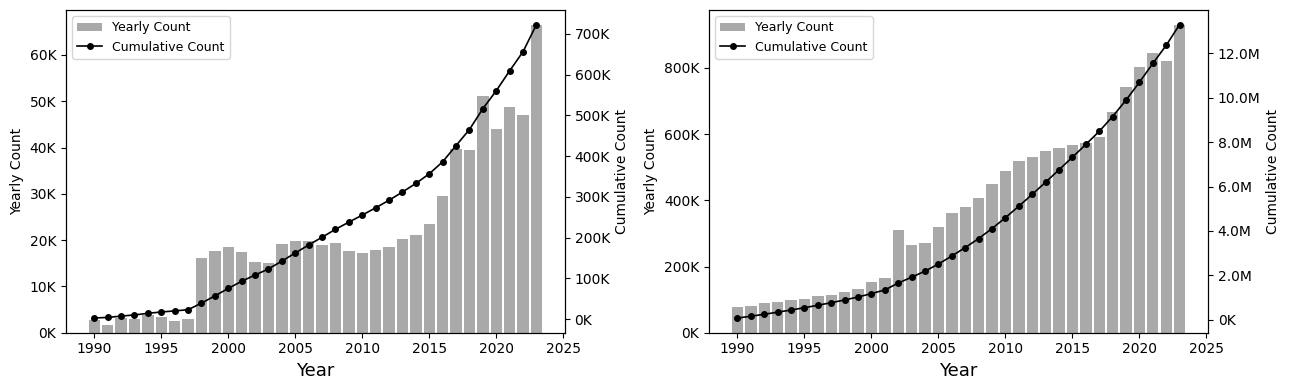

In [8]:
# ── 이벤트 정의
NEWS_EVENTS = {
    1997: "Deep Blue defeats Kasparov",
    2011: "IBM Watson wins Jeopardy!",
    2016: "AlphaGo defeats Lee Sedol",
    2022: "ChatGPT release",
}
PAPER_EVENTS = {
    1986: "Backprop (MLP)",
    1995: "SVM",
    2006: "DBN & NVIDIA CUDA",
    2012: "AlexNet (CNN)",
    2017: "Attention is All You Need",
    2020: "GPT-3",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, docs, events, title in zip(
    axes,
    [news_docs, paper_docs],
    [NEWS_EVENTS, PAPER_EVENTS],
    ['News Articles', 'Academic Papers'],
):
    ax2 = ax.twinx()  # ← 루프 안에서 생성
    yrs = sorted(docs.index)
    vals = docs.reindex(yrs, fill_value=0)
    cumvals = vals.cumsum()
    bar = ax.bar(yrs, vals.values, color='darkgrey', width=0.85, label='Yearly Count') #edgecolor='black', linewidth=0.8,
    line, = ax2.plot(yrs, cumvals.values, color='black', lw=1.2, marker='o', markersize=4, label='Cumulative Count')
    prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    # event_colors = ['blue', 'green', 'red', 'gold', 'purple', 'orange']
    # event_lines = []
    # for i, (yr, label) in enumerate(events.items()):
    #     if yr in yrs:
    #         vl = ax.axvline(yr, color=event_colors[i % len(event_colors)], lw=1.2, ls='--', alpha=0.9, label=label)
    #         event_lines.append(vl)
    handles = [bar, line] #+ event_lines
    ax.legend(handles=handles, fontsize=9, loc='upper left', framealpha=0.8)
    ax2.set_ylabel('Cumulative Count', fontsize=10)
    ax.set_xlabel('Year', fontsize=13)
    ax.set_ylabel('Yearly Count', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig(PLOT_DIR / 'desc1_yearly_cumulative.png', dpi=300, bbox_inches='tight')
plt.show()

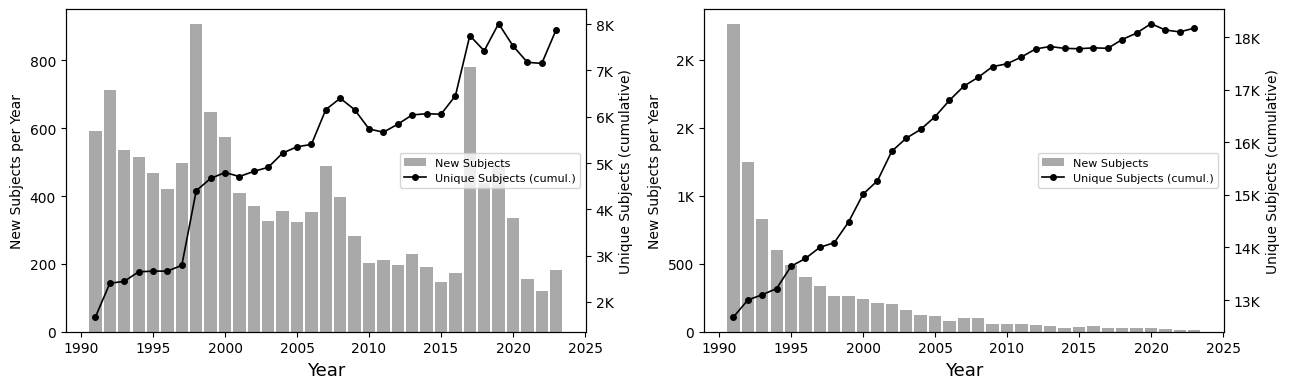

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, new_s, uniq_s, events, title in zip(
    axes,
    [news_new, paper_new],
    [news_uniq, paper_uniq],
    [NEWS_EVENTS, PAPER_EVENTS],
    ['News Articles', 'Academic Papers'],
):
    yrs = sorted(new_s.index)[1:]  # 첫 해 제외
    ax2 = ax.twinx()
    bar = ax.bar(yrs, new_s.reindex(yrs, fill_value=0).values,
                 color='darkgrey', width=0.85, label='New Subjects')
    line, = ax2.plot(yrs, uniq_s.reindex(yrs, fill_value=0).values,
                     color='black', lw=1.2, marker='o', markersize=4, label='Unique Subjects (cumul.)')
    # event_colors = ['blue', 'green', 'red', 'gold', 'purple', 'orange']
    # event_lines = []
    # for i, (yr, label) in enumerate(events.items()):
    #     if yr in yrs:
    #         vl = ax.axvline(yr, color=event_colors[i % len(event_colors)],
    #                         lw=1.2, ls='--', alpha=0.9, label=label)
    #         event_lines.append(vl)
    handles = [bar, line] #+ event_lines
    ax.legend(handles=handles, fontsize=8, loc='center right', framealpha=0.8)
    ax.set_xlabel('Year', fontsize=13)
    ax.set_ylabel('New Subjects per Year', fontsize=10)
    ax2.set_ylabel('Unique Subjects (cumulative)', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1000 else f'{x:.0f}'))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1000 else f'{x:.0f}'))

plt.tight_layout()
plt.savefig(PLOT_DIR / 'desc2_new_unique_subjects.png', dpi=300, bbox_inches='tight')
plt.show()

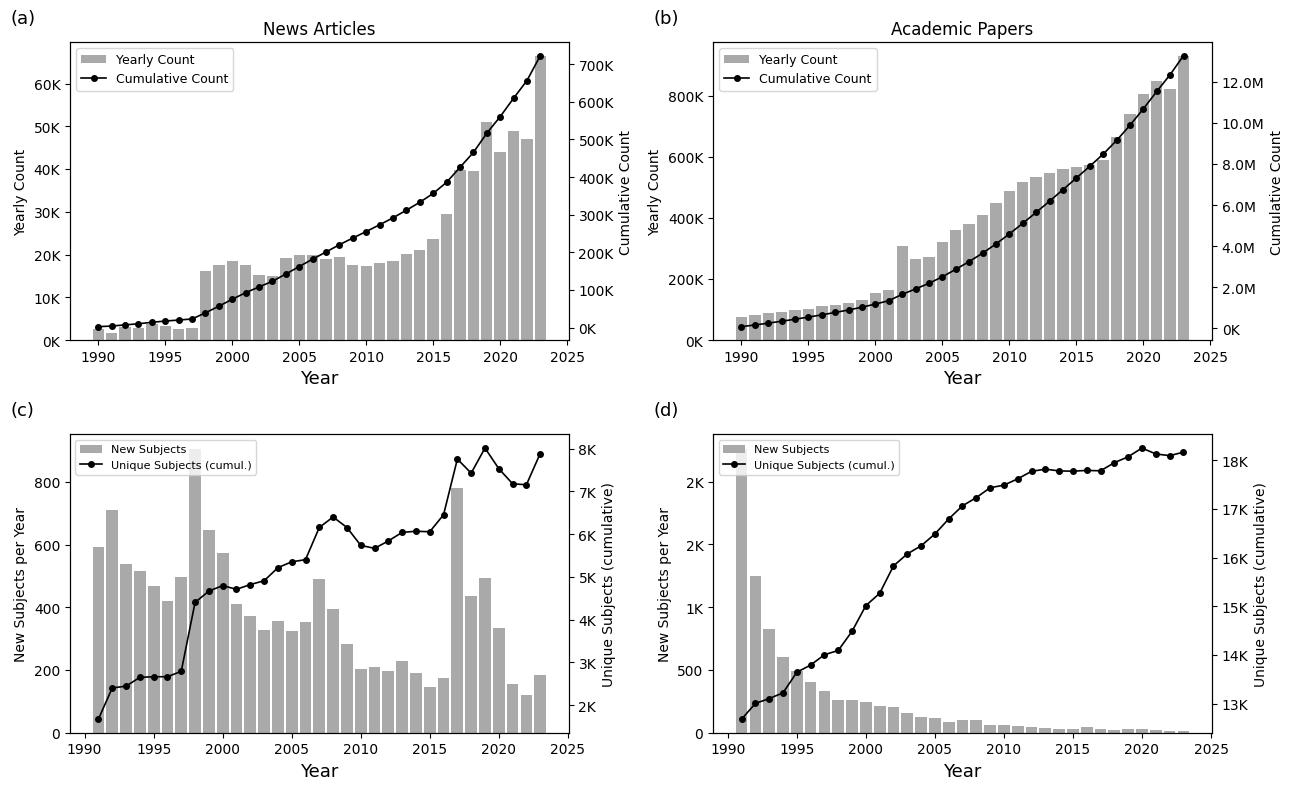

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ── 상단 행 (a, b): 연도별 & 누적 문서 수
top_data = [
    (axes[0, 0], news_docs, 'News Articles'),
    (axes[0, 1], paper_docs, 'Academic Papers'),
]
for ax, docs, col_title in top_data:
    ax2 = ax.twinx()
    yrs = sorted(docs.index)
    vals = docs.reindex(yrs, fill_value=0)
    cumvals = vals.cumsum()
    bar = ax.bar(yrs, vals.values, color='darkgrey', width=0.85, label='Yearly Count')
    line, = ax2.plot(yrs, cumvals.values, color='black', lw=1.2, marker='o', markersize=4, label='Cumulative Count')

    ax.set_title(col_title, fontsize=12)
    ax.legend(handles=[bar, line], fontsize=9, loc='upper left', framealpha=0.8)
    ax2.set_ylabel('Cumulative Count', fontsize=10)
    ax.set_xlabel('Year', fontsize=13)
    ax.set_ylabel('Yearly Count', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))

# ── 하단 행 (c, d): 신규 & 누적 고유 subject 수
bottom_data = [
    (axes[1, 0], news_new, news_uniq),
    (axes[1, 1], paper_new, paper_uniq),
]
for ax, new_s, uniq_s in bottom_data:
    yrs = sorted(new_s.index)[1:]  # 첫 해 제외
    ax2 = ax.twinx()
    bar = ax.bar(yrs, new_s.reindex(yrs, fill_value=0).values,
                 color='darkgrey', width=0.85, label='New Subjects')
    line, = ax2.plot(yrs, uniq_s.reindex(yrs, fill_value=0).values,
                     color='black', lw=1.2, marker='o', markersize=4, label='Unique Subjects (cumul.)')
    ax.legend(handles=[bar, line], fontsize=8, loc='upper left', framealpha=0.8)
    ax.set_xlabel('Year', fontsize=13)
    ax.set_ylabel('New Subjects per Year', fontsize=10)
    ax2.set_ylabel('Unique Subjects (cumulative)', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1000 else f'{x:.0f}'))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1000 else f'{x:.0f}'))

# ── (a)(b)(c)(d) 라벨 (볼드 없음)
for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.text(-0.12, 1.05, label, transform=ax.transAxes,
            fontsize=13, fontweight='normal', va='bottom', ha='left')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'desc_combined.png', dpi=300, bbox_inches='tight')
plt.show()

## Network construction

### Base network construction

In [37]:
def build_network(grouped, output_dir, source, year):
    subjects = sorted(set(s for doc in grouped for s in doc))
    subj_idx = {s: i for i, s in enumerate(subjects)}
    n = len(subjects)
    matrix = lil_matrix((n, n), dtype=np.float32)

    for doc_subjects in grouped:
        unique = list(set(doc_subjects))
        d = len(unique)
        if d < 2:
            continue
        w = 1 / (d - 1)
        # 이중 루프 대신 combinations로 절반만 계산 후 대칭 처리
        idx = [subj_idx[s] for s in unique]
        for i, j in combinations(idx, 2):
            matrix[i, j] += w
            matrix[j, i] += w

    csr = matrix.tocsr()
    csr.setdiag(0)
    csr.eliminate_zeros()

    save_npz(output_dir / f"{source}_{year}_adj.npz", csr)
    with open(output_dir / f"{source}_{year}_subjects.pkl", "wb") as f:
        pickle.dump(subjects, f)
        
for source, df in [("news", news_df), ("paper", paper_df)]:
    by_year = {
        year: group.groupby("id")["subject"].apply(list)
        for year, group in df.groupby("year")
    }
    for year, grouped in tqdm(by_year.items(), desc=source):
        build_network(grouped, NETWORKS_DIR, source, year)

news:   0%|          | 0/34 [00:00<?, ?it/s]

paper:   0%|          | 0/34 [00:00<?, ?it/s]

### Edge filtering threshold check

In [38]:

SOURCES_TO_PROFILE = ["news", "paper"]
THRESHOLD_YEARS = [2022, 2023]
THRESHOLDS = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

def sparse_basic_stats(adj):
    n = adj.shape[0]
    m = adj.nnz // 2  # 대칭 행렬이므로
    if n == 0:
        return {"nodes": 0, "edges": 0, "avg_degree": 0.0, "largest_cc_nodes": 0, "largest_cc_share": 0.0}
    avg_degree = 2 * m / n if n else 0.0

    # largest connected component
    n_components, labels = connected_components(adj, directed=False)
    largest_cc_nodes = max(np.bincount(labels))

    return {
        "nodes": n,
        "edges": m,
        "avg_degree": avg_degree,
        "largest_cc_nodes": largest_cc_nodes,
        "largest_cc_share": largest_cc_nodes / n,
    }

def filter_sparse(adj, threshold, drop_isolates=True):
    if threshold > 0:
        adj = adj.multiply(adj >= threshold)
        adj.eliminate_zeros()
    if drop_isolates:
        degrees = np.array(adj.sum(axis=1)).flatten()
        keep = np.where(degrees > 0)[0]
        adj = adj[keep][:, keep]
    return adj

def threshold_profile(adj, thresholds, drop_isolates=True):
    raw_stats = sparse_basic_stats(adj)
    n0, m0 = raw_stats["nodes"], raw_stats["edges"]
    rows = []
    for t in thresholds:
        filtered = filter_sparse(adj, t, drop_isolates=drop_isolates)
        stats = sparse_basic_stats(filtered)
        rows.append({
            "min_edge_weight": t,
            **stats,
            "node_retention": stats["nodes"] / n0 if n0 else 0.0,
            "edge_retention": stats["edges"] / m0 if m0 else 0.0,
        })
    return pd.DataFrame(rows)

# 실행
profile_frames = []
for source in SOURCES_TO_PROFILE:
    for year in THRESHOLD_YEARS:
        adj = load_npz(NETWORKS_DIR / f"{source}_{year}_adj.npz")
        df = threshold_profile(adj, THRESHOLDS, drop_isolates=True)
        df.insert(0, "source", source)
        df.insert(1, "year", year)
        df.insert(2, "raw_nodes", adj.shape[0])
        df.insert(3, "raw_edges", adj.nnz // 2)
        profile_frames.append(df)

profile = pd.concat(profile_frames, ignore_index=True)
display(profile)

summary = (
    profile
    .groupby(["source", "min_edge_weight"], as_index=False)
    .agg(
        nodes_mean=("nodes", "mean"),
        nodes_min=("nodes", "min"),
        edges_mean=("edges", "mean"),
        edges_min=("edges", "min"),
        avg_degree_mean=("avg_degree", "mean"),
        node_retention_mean=("node_retention", "mean"),
        node_retention_min=("node_retention", "min"),
        edge_retention_mean=("edge_retention", "mean"),
        largest_cc_share_mean=("largest_cc_share", "mean"),
        largest_cc_share_min=("largest_cc_share", "min"),
    )
)
summary = summary.sort_values(["source", "min_edge_weight"]).reset_index(drop=True)
display(summary)

,source,year,raw_nodes,raw_edges,min_edge_weight,nodes,edges,avg_degree,largest_cc_nodes,largest_cc_share,node_retention,edge_retention
0,news,2022,7153,362604,0.00,7151,362604,101.413509,7151,1.000000,0.999720,1.000000
1,news,2022,7153,362604,0.10,6689,243031,72.665869,6689,1.000000,0.935132,0.670238
2,news,2022,7153,362604,0.25,5399,104596,38.746435,5395,0.999259,0.754788,0.288458
3,news,2022,7153,362604,0.50,4010,48265,24.072319,3998,0.997007,0.560604,0.133107
4,news,2022,7153,362604,0.75,3155,30130,19.099842,3143,0.996197,0.441074,0.083093
5,news,2022,7153,362604,1.00,2728,22045,16.162023,2716,0.995601,0.381378,0.060796
6,news,2022,7153,362604,1.50,2050,13893,13.554146,2044,0.997073,0.286593,0.038315
7,news,2022,7153,362604,2.00,1689,10010,11.853168,1683,0.996448,0.236125,0.027606
8,news,2023,7883,445010,0.00,7883,445010,112.903717,7883,1.000000,1.000000,1.000000
9,news,2023,7883,445010,0.10,7394,299779,81.087098,7394,1.000000,0.937968,0.673646


,source,min_edge_weight,nodes_mean,nodes_min,edges_mean,edges_min,avg_degree_mean,node_retention_mean,node_retention_min,edge_retention_mean,largest_cc_share_mean,largest_cc_share_min
0,news,0.00,7517.0,7151,403807.0,362604,107.158613,0.999860,0.999720,1.000000,1.000000,1.000000
1,news,0.10,7041.5,6689,271405.0,243031,76.876483,0.936550,0.935132,0.671942,1.000000,1.000000
2,news,0.25,5734.5,5399,117535.0,104596,40.868110,0.762400,0.754788,0.290826,0.999630,0.999259
3,news,0.50,4343.5,4010,54978.0,48265,25.226453,0.576953,0.560604,0.135867,0.997648,0.997007
4,news,0.75,3474.0,3155,34555.5,30130,19.827010,0.461118,0.441074,0.085345,0.997044,0.996197
5,news,1.00,3043.0,2728,25454.5,22045,16.676604,0.403679,0.381378,0.062829,0.995716,0.995601
6,news,1.50,2289.5,2050,16046.5,13893,13.973594,0.303705,0.286593,0.039606,0.998141,0.997073
7,news,2.00,1895.5,1689,11563.0,10010,12.166355,0.251387,0.236125,0.028540,0.997748,0.996448
8,paper,0.00,18124.5,18090,1982103.0,1954473,218.715836,0.999531,0.999505,1.000000,0.999890,0.999889
9,paper,0.10,18106.5,18074,1942489.5,1914407,214.557794,0.998539,0.998404,0.980007,0.999890,0.999889


### Edge filtering

In [39]:
def filter_network(source, year, threshold=0.5):
    adj = load_npz(NETWORKS_DIR / f"{source}_{year}_adj.npz")
    with open(NETWORKS_DIR / f"{source}_{year}_subjects.pkl", "rb") as f:
        subjects = pickle.load(f)

    adj_filtered = adj.multiply(adj >= threshold)
    adj_filtered.eliminate_zeros()

    # 고립 노드 제거
    degrees = np.array(adj_filtered.sum(axis=1)).flatten()
    keep = np.where(degrees > 0)[0]
    adj_filtered = adj_filtered[keep][:, keep]
    subjects_filtered = [subjects[i] for i in keep]

    save_npz(NETWORKS_DIR / f"{source}_{year}_adj_t{threshold}.npz", adj_filtered)
    with open(NETWORKS_DIR / f"{source}_{year}_subjects_t{threshold}.pkl", "wb") as f:
        pickle.dump(subjects_filtered, f)

for source, threshold in EDGE_THRESHOLDS.items():
    for year in tqdm(range(YEAR_START, YEAR_END + 1), desc=f"filter {source}"):
        filter_network(source, year, threshold=threshold)

filter news:   0%|          | 0/34 [00:00<?, ?it/s]

filter paper:   0%|          | 0/34 [00:00<?, ?it/s]

In [81]:
import shutil

# news 원본을 t0.0으로 복사
for year in years:
    src = NETWORKS_DIR / f"news_{year}_adj.npz"
    dst = NETWORKS_DIR / f"news_{year}_adj_t0.0.npz"
    shutil.copy(src, dst)
    
    src_s = NETWORKS_DIR / f"news_{year}_subjects.pkl"
    dst_s = NETWORKS_DIR / f"news_{year}_subjects_t0.0.pkl"
    shutil.copy(src_s, dst_s)

## Network analysis

In [13]:
warnings.filterwarnings("ignore")

COLORS  = {"news": "#E8593C", "paper": "#3B8BD4"}
YEARS   = list(range(YEAR_START, YEAR_END + 1))
PROFILE_YEARS = [2000, 2005, 2010, 2015, 2020, YEAR_END]  # spot-check years for distributions

# ── Helper ───────────────────────────────────────────────────

def load_network(source, year, threshold):
    adj_path  = NETWORKS_DIR / f"{source}_{year}_adj_t{threshold}.npz"
    subj_path = NETWORKS_DIR / f"{source}_{year}_subjects_t{threshold}.pkl"
    if not adj_path.exists():
        return None, None
    adj = load_npz(adj_path)
    with open(subj_path, "rb") as f:
        subjects = pickle.load(f)
    return adj, subjects


def basic_stats(adj):
    n   = adj.shape[0]
    m   = adj.nnz // 2
    deg = np.array(adj.sum(axis=1)).flatten()

    # edge weights (upper triangle to avoid duplicates)
    upper   = triu(adj, k=1)
    weights = upper.data

    _, labels = connected_components(adj, directed=False)
    lcc       = np.bincount(labels).max()

    return {
        "n"             : n,
        "m"             : m,
        "density"       : (2 * m) / (n * (n - 1)) if n > 1 else 0,
        "deg_mean"      : deg.mean(),
        "deg_std"       : deg.std(),
        "deg_skew"      : sp_stats.skew(deg),
        "deg_max"       : deg.max(),
        "w_mean"        : weights.mean()        if len(weights) else 0,
        "w_std"         : weights.std()         if len(weights) else 0,
        "w_p50"         : np.percentile(weights, 50)  if len(weights) else 0,
        "w_p90"         : np.percentile(weights, 90)  if len(weights) else 0,
        "w_p99"         : np.percentile(weights, 99)  if len(weights) else 0,
        "w_max"         : weights.max()         if len(weights) else 0,
        "lcc_share"     : lcc / n,
        # normalization reference: what threshold captures top X% of weights?
        "w_q90_val"     : np.percentile(weights, 90)  if len(weights) else 0,
    }

Descriptive statistics — full-period mean (± std)
  n                   news=    5220.794 (±1824.466)   paper=   11625.529 (±2483.359)   ratio=  2.23x
  m                   news=  182415.912 (±111858.985)   paper=  294184.735 (±168960.570)   ratio=  1.61x
  density             news=       0.012 (±   0.001)   paper=       0.004 (±   0.001)   ratio=  0.32x
  deg_mean            news=      22.979 (±  11.603)   paper=     135.999 (±  85.573)   ratio=  5.92x
  deg_std             news=     169.328 (± 108.327)   paper=    1111.874 (± 706.212)   ratio=  6.57x
  deg_skew            news=      36.121 (±  10.681)   paper=      33.582 (±   2.437)   ratio=  0.93x
  deg_max             news=    9833.002 (±6939.575)   paper=   65144.410 (±38339.156)   ratio=  6.63x
  w_mean              news=       0.348 (±   0.076)   paper=       2.642 (±   0.664)   ratio=  7.59x
  w_std               news=       2.102 (±   1.066)   paper=      14.708 (±   7.300)   ratio=  7.00x
  w_p50               news=       0.

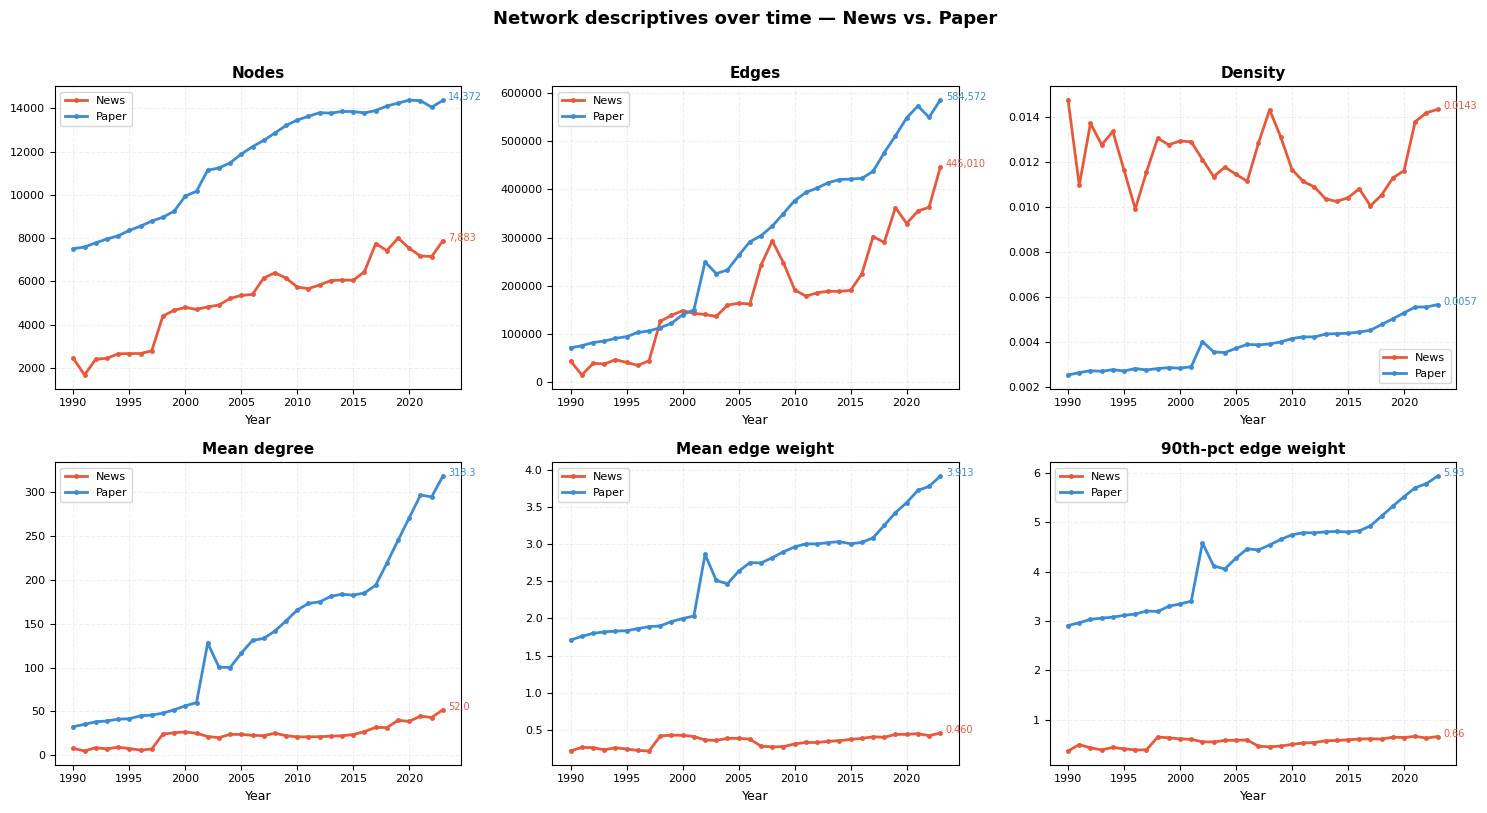


KeyboardInterrupt



In [12]:
# ── 1. Collect stats across all years ────────────────────────

rows = []
for source, thr in EDGE_THRESHOLDS.items():
    for year in YEARS:
        adj, subj = load_network(source, year, thr)
        if adj is None:
            continue
        s = basic_stats(adj)
        rows.append({"source": source, "year": year, **s})

df = pd.DataFrame(rows).sort_values(["source", "year"]).reset_index(drop=True)
news_ts  = df[df.source == "news"].set_index("year")
paper_ts = df[df.source == "paper"].set_index("year")

# ── 2. Summary table ─────────────────────────────────────────

print("=" * 72)
print("Descriptive statistics — full-period mean (± std)")
print("=" * 72)

cols = ["n", "m", "density",
        "deg_mean", "deg_std", "deg_skew", "deg_max",
        "w_mean", "w_std", "w_p50", "w_p90", "w_p99", "w_max",
        "lcc_share"]

for col in cols:
    n_vals = df[df.source == "news"][col]
    p_vals = df[df.source == "paper"][col]
    ratio  = p_vals.mean() / n_vals.mean() if n_vals.mean() != 0 else np.nan
    print(f"  {col:<18}  news={n_vals.mean():>12.3f} (±{n_vals.std():>8.3f})"
          f"   paper={p_vals.mean():>12.3f} (±{p_vals.std():>8.3f})"
          f"   ratio={ratio:>6.2f}x")

# ── 3. Time-series panel ──────────────────────────────────────

ts_metrics = [
    ("n",         "Nodes",                  "{:,.0f}"),
    ("m",         "Edges",                  "{:,.0f}"),
    ("density",   "Density",                "{:.4f}"),
    ("deg_mean",  "Mean degree",            "{:.1f}"),
    ("w_mean",    "Mean edge weight",       "{:.3f}"),
    ("w_p90",     "90th-pct edge weight",  "{:.2f}"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (col, title, fmt) in zip(axes, ts_metrics):
    for source, ts in [("news", news_ts), ("paper", paper_ts)]:
        vals = ts[col]
        ax.plot(vals.index, vals.values,
                color=COLORS[source], lw=2, label=source.capitalize(),
                marker="o", ms=2.5)
        # annotate last value
        ax.annotate(fmt.format(vals.iloc[-1]),
                    xy=(vals.index[-1], vals.iloc[-1]),
                    xytext=(4, 0), textcoords="offset points",
                    fontsize=7, color=COLORS[source])
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Year", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2, ls="--")
    ax.tick_params(labelsize=8)

plt.suptitle("Network descriptives over time — News vs. Paper",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(CP_DIR / "net_desc_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 4. Degree & weight distributions (spot-check years) ───────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax_deg_hist, ax_deg_cdf = axes[0]
ax_w_hist,   ax_w_cdf   = axes[1]

for source, thr in EDGE_THRESHOLDS.items():
    for year in PROFILE_YEARS:
        adj, subj = load_network(source, year, thr)
        if adj is None:
            continue

        deg     = np.array(adj.sum(axis=1)).flatten()
        weights = triu(adj, k=1).data
        alpha   = 0.55
        lw      = 1.4
        color   = COLORS[source]

        # degree histogram (log-log)
        counts, bins = np.histogram(deg, bins=50)
        mids = (bins[:-1] + bins[1:]) / 2
        mask = counts > 0
        ax_deg_hist.plot(mids[mask], counts[mask],
                         color=color, alpha=alpha, lw=lw)

        # degree CDF
        sorted_d = np.sort(deg)
        cdf      = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
        ax_deg_cdf.plot(sorted_d, 1 - cdf,
                        color=color, alpha=alpha, lw=lw)

        # weight histogram
        counts_w, bins_w = np.histogram(weights, bins=60)
        mids_w = (bins_w[:-1] + bins_w[1:]) / 2
        mask_w = counts_w > 0
        ax_w_hist.plot(mids_w[mask_w], counts_w[mask_w],
                       color=color, alpha=alpha, lw=lw)

        # weight CDF
        sorted_w = np.sort(weights)
        cdf_w    = np.arange(1, len(sorted_w) + 1) / len(sorted_w)
        ax_w_cdf.plot(sorted_w, 1 - cdf_w,
                      color=color, alpha=alpha, lw=lw)

# formatting
for ax, title, xlab, ylab, xscale, yscale in [
    (ax_deg_hist, "Degree distribution",           "Degree",      "Count",       "log", "log"),
    (ax_deg_cdf,  "Degree CCDF (1−CDF)",           "Degree",      "P(X > x)",    "log", "log"),
    (ax_w_hist,   "Edge weight distribution",       "Weight",      "Count",       "log", "log"),
    (ax_w_cdf,    "Edge weight CCDF (1−CDF)",       "Weight",      "P(X > x)",    "log", "log"),
]:
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlab, fontsize=9);  ax.set_ylabel(ylab, fontsize=9)
    ax.set_xscale(xscale);            ax.set_yscale(yscale)
    ax.grid(alpha=0.2, ls="--");      ax.tick_params(labelsize=8)

legend_elements = [
    Line2D([0], [0], color=COLORS["news"],  lw=2, label="News"),
    Line2D([0], [0], color=COLORS["paper"], lw=2, label="Paper"),
]
for ax in axes.flatten():
    ax.legend(handles=legend_elements, fontsize=8)

plt.suptitle(f"Degree & weight distributions ({', '.join(map(str, PROFILE_YEARS))})",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(CP_DIR / "net_desc_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. Normalization reference ────────────────────────────────

print("\n")
print("=" * 72)
print("Within-network weight normalization reference")
print("(What fraction of edges fall above the current threshold?)")
print("=" * 72)

for source, thr in EDGE_THRESHOLDS.items():
    vals = []
    for year in YEARS:
        adj, subj = load_network(source, year, thr)
        if adj is None: continue
        w = triu(adj, k=1).data
        if len(w):
            vals.append({"year": year,
                         "w_mean": w.mean(), "w_std": w.std(),
                         "w_p50": np.percentile(w, 50),
                         "w_p90": np.percentile(w, 90),
                         "w_p95": np.percentile(w, 95),
                         "w_p99": np.percentile(w, 99)})
    vdf = pd.DataFrame(vals)
    print(f"\n  {source.upper()} (threshold={thr})")
    print(f"  {'year':<6}  {'mean':>6}  {'p50':>6}  {'p90':>6}  "
          f"{'p95':>6}  {'p99':>6}  {'std':>6}")
    for _, r in vdf.iterrows():
        print(f"  {int(r.year):<6}  {r.w_mean:>6.3f}  {r.w_p50:>6.3f}  "
              f"{r.w_p90:>6.3f}  {r.w_p95:>6.3f}  {r.w_p99:>6.3f}  {r.w_std:>6.3f}")

print("\nSaved: net_desc_timeseries.png, net_desc_distributions.png")

## Network normalization

In [3]:
def symmetric_normalize(source, year, threshold):
    adj = load_npz(NETWORKS_DIR / f"{source}_{year}_adj_t{threshold}.npz")

    d     = np.array(adj.sum(axis=1)).flatten()
    d_inv = np.where(d > 0, d ** -0.5, 0.0)
    D_inv = diags(d_inv)

    adj_norm = D_inv @ adj @ D_inv

    save_npz(
        NETWORKS_DIR / f"{source}_{year}_adj_t{threshold}_symnorm.npz",
        adj_norm.tocsr()
    )

years = list(range(YEAR_START, YEAR_END + 1))

for source, thr in EDGE_THRESHOLDS.items():
    for year in tqdm(years, desc=f"symnorm {source}"):
        symmetric_normalize(source, year, thr)

symnorm news:   0%|          | 0/34 [00:00<?, ?it/s]

/tmp/ipykernel_15689/3435715440.py:5: RuntimeWarning: divide by zero encountered in power
  d_inv = np.where(d > 0, d ** -0.5, 0.0)


symnorm paper:   0%|          | 0/34 [00:00<?, ?it/s]

## Core-periphery analysis

### Analysis

In [ ]:
def compute_herfindahl(coreness, pair_id):
    core_nodes = {k for k, v in coreness.items() if v == 1}
    if not core_nodes:
        return 0.0
    cluster_counts = {}
    for k in core_nodes:
        cid = pair_id[k]
        cluster_counts[cid] = cluster_counts.get(cid, 0) + 1
    total = sum(cluster_counts.values())
    return sum((c / total) ** 2 for c in cluster_counts.values())


def compute_cit(source, threshold, years, metrics_by_year):
    cit_list = []
    for i, year in enumerate(years):
        if i == 0:
            cit_list.append({"year": year, "cit_mean": np.nan, "cit_ci": np.nan})
            continue

        prev_year = years[i - 1]
        curr_m = metrics_by_year[year]
        prev_m = metrics_by_year[prev_year]

        curr_subjects = curr_m["subjects"]
        prev_subjects = prev_m["subjects"]

        curr_idx = {s: i for i, s in enumerate(curr_subjects)}
        prev_idx = {s: i for i, s in enumerate(prev_subjects)}
        common = sorted(set(curr_subjects) & set(prev_subjects))

        if not common:
            cit_list.append({"year": year, "cit_mean": np.nan, "cit_ci": np.nan})
            continue

        cit_runs = []
        for r in range(N_RUNS):
            curr_labels = curr_m["labels_per_run"][r]
            prev_labels = prev_m["labels_per_run"][r]

            # 현재 시점 전체 core (공통 노드 한정 아니고 현재 전체)
            curr_core_all = [s for s in curr_subjects if curr_labels[curr_idx[s]] == 1]
            if not curr_core_all:
                continue

            # 그 중 이전 시점에도 존재했고 core였던 것
            overlap = sum(
                1 for s in curr_core_all
                if s in prev_idx and prev_labels[prev_idx[s]] == 1
            )
            cit_runs.append(1 - overlap / len(curr_core_all))

        if cit_runs:
            cit_list.append({
                "year": year,
                "cit_mean": np.mean(cit_runs),
                "cit_ci": 1.96 * np.std(cit_runs) / np.sqrt(len(cit_runs)),
            })
        else:
            cit_list.append({"year": year, "cit_mean": np.nan, "cit_ci": np.nan})

    return pd.DataFrame(cit_list)
    

def run_single(adj_path, subjects_path):
    """단일 run 실행"""
    import pickle, cpnet
    adj = load_npz(adj_path)
    with open(subjects_path, "rb") as f:
        subjects = pickle.load(f)
    km = cpnet.KM_ER()
    km.detect(adj)
    coreness = km.get_coreness()
    pair_id = km.get_pair_id()
    n = len(subjects)
    labels = np.array([coreness.get(i, 0) for i in range(n)])
    core_nodes = {k for k, v in coreness.items() if v == 1}
    core_clusters = {pair_id[k] for k in core_nodes}
    herf = compute_herfindahl(coreness, pair_id)
    return {
        "labels": labels,
        "rit": len(core_nodes) / n,
        "sit": len(core_clusters),
        "herfindahl": herf,
    }

    
def run_cp_year(source, year, threshold, n_runs=N_RUNS):
    adj = load_npz(NETWORKS_DIR / f"{source}_{year}_adj_t{threshold}_symnorm.npz")
    with open(NETWORKS_DIR / f"{source}_{year}_subjects_t{threshold}.pkl", "rb") as f:
        subjects = pickle.load(f)

    n = len(subjects)    
    results = Parallel(n_jobs=N_RUNS)(
        delayed(run_single)(
            NETWORKS_DIR / f"{source}_{year}_adj_t{threshold}_symnorm.npz",
            NETWORKS_DIR / f"{source}_{year}_subjects_t{threshold}.pkl"
        )
        for _ in range(n_runs)
    )

    labels_per_run = [res["labels"] for res in results]
    rit_runs = [res["rit"] for res in results]
    sit_runs = [res["sit"] for res in results]
    herf_runs = [res["herfindahl"] for res in results]

    # run별 저장 (재현성용)
    for r, res in enumerate(results):
        pd.DataFrame({
            "subject": subjects,
            "cp_label": res["labels"],
        }).to_csv(CP_DIR / f"{source}_{year}_cp_run{r}_t{threshold}_symnorm.csv", index=False)

    # majority vote
    core_counts = np.sum(labels_per_run, axis=0)
    core_prob = core_counts / n_runs
    cp_label = (core_prob >= 0.5).astype(int)

    pd.DataFrame({
        "subject": subjects,
        "core_prob": core_prob,
        "cp_label": cp_label,
    }).to_csv(CP_DIR / f"{source}_{year}_cp_t{threshold}_symnorm.csv", index=False)

    return {
        "year": year,
        "source": source,
        "rit_mean": np.mean(rit_runs),
        "rit_ci": 1.96 * np.std(rit_runs) / np.sqrt(n_runs),
        "sit_mean": np.mean(sit_runs),
        "sit_ci": 1.96 * np.std(sit_runs) / np.sqrt(n_runs),
        "herfindahl_mean": np.mean(herf_runs),
        "herfindahl_ci": 1.96 * np.std(herf_runs) / np.sqrt(n_runs),
        "labels_per_run": labels_per_run,  # 메모리 유지
        "subjects": subjects,
    }

In [ ]:
# 실행: 연도는 순차, run은 내부에서 병렬

for source, threshold in EDGE_THRESHOLDS.items():
    metrics_list = [
        run_cp_year(source, year, threshold)
        for year in tqdm(years, desc=f"CP {source}")
    ]

    metrics_by_year = {m["year"]: m for m in metrics_list}
    cit_df = compute_cit(source, threshold, years, metrics_by_year)

    metrics_df = pd.DataFrame([
        {k: v for k, v in m.items() if k not in ("labels_per_run", "subjects")}
        for m in metrics_list
    ]).sort_values("year").reset_index(drop=True)

    metrics_df = metrics_df.merge(cit_df, on="year")
    metrics_df.to_csv(CP_DIR / f"{source}_cp_metrics_t{threshold}_symnorm.csv", index=False)

In [3]:
yr = 2020
thr = EDGE_THRESHOLDS['paper']
cp_sym = pd.read_csv(CP_DIR / f'paper_{yr}_cp_t{thr}_symnorm.csv')
cp_raw = pd.read_csv(CP_DIR / f'paper_{yr}_cp_t{thr}.csv')  # 있다면
merged = cp_sym.merge(cp_raw, on='subject', suffixes=('_sym','_raw'))
diff = (merged['cp_label_sym'] != merged['cp_label_raw']).mean()
print(f'label 불일치 비율: {diff:.1%}')

label 불일치 비율: 38.7%


In [5]:
print('symnorm core 비율:', cp_sym['cp_label'].mean())
print('raw core 비율:', cp_raw['cp_label'].mean())

symnorm core 비율: 0.4312621629135391
raw core 비율: 0.26591604114539896


### Plot

In [3]:
MIN_YEAR = YEAR_START
MAX_YEAR = YEAR_END
YEAR_TICKS = list(range(YEAR_START, YEAR_END + 1, 5))

# 데이터 로드
news_df = pd.read_csv(CP_DIR / f"news_cp_metrics_t{EDGE_THRESHOLDS['news']}_symnorm.csv")
paper_df = pd.read_csv(CP_DIR / f"paper_cp_metrics_t{EDGE_THRESHOLDS['paper']}_symnorm.csv")

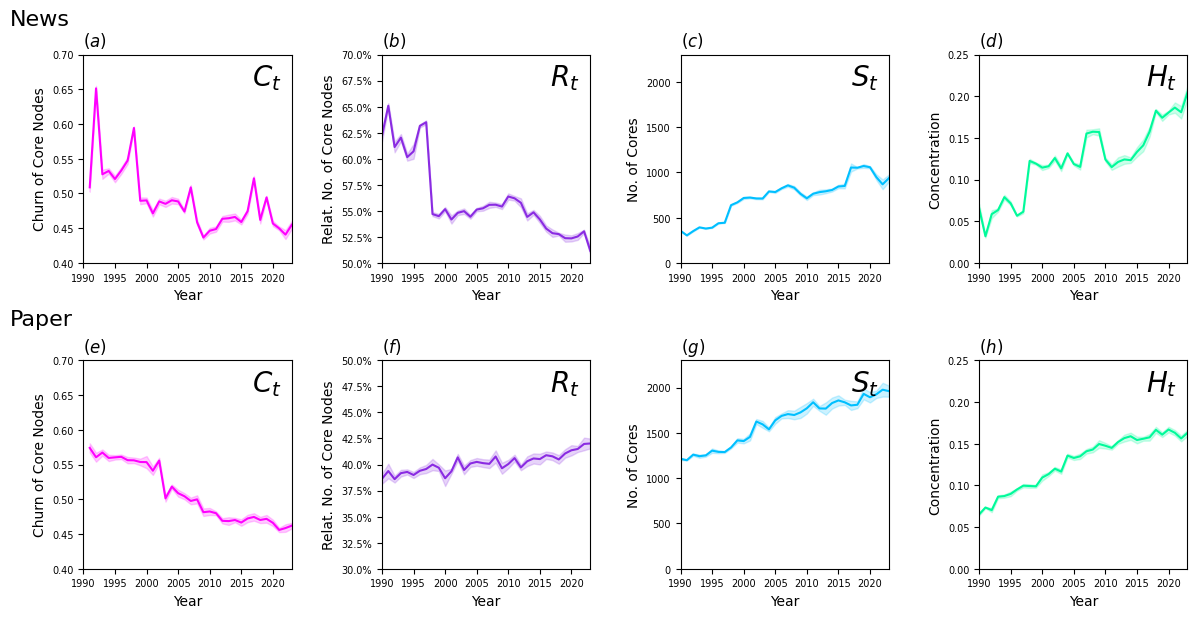

In [4]:
def plot_metric(ax, df, measure, ci_col, color, ylabel, ylim, title_label, math_label, year_ticks, pct=False):
    plot_df = df.dropna(subset=[measure])
    sns.lineplot(data=plot_df, x="year", y=measure, color=color, errorbar=None, ax=ax)
    ax.fill_between(plot_df["year"],
                    plot_df[measure] - plot_df[ci_col],
                    plot_df[measure] + plot_df[ci_col],
                    color=color, alpha=0.2)
    ax.set_xlim(MIN_YEAR, MAX_YEAR)
    ax.set_xticks(year_ticks)
    ax.set_ylim(*ylim)
    ax.set_aspect(1 / ax.get_data_ratio())
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    if pct:
        ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1.0))
    ax.set_title(rf"${{({title_label})}}$", loc="left")
    ax.text(0.95, 0.85, f"${math_label}$",
            transform=ax.transAxes,
            horizontalalignment="right",
            size=20)

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.flat

configs = [
    # (df, measure, ci_col, color, ylabel, ylim, title, math, pct)
    (news_df,  "cit_mean",          "cit_ci",          "#FF00FF",        "Churn of Core Nodes",        (0.4, 0.7),   "a", "C_{t}", False),
    (news_df,  "rit_mean",          "rit_ci",          "#8A2BE2",        "Relat. No. of Core Nodes",   (0.5, 0.7),   "b", "R_{t}", True),
    (news_df,  "sit_mean",          "sit_ci",          "#00BFFF",        "No. of Cores",               (0, 2300),    "c", "S_{t}", False),
    (news_df,  "herfindahl_mean",   "herfindahl_ci",   "mediumspringgreen", "Concentration",           (0.0, 0.25),  "d", "H_{t}", False),
    (paper_df, "cit_mean",          "cit_ci",          "#FF00FF",        "Churn of Core Nodes",        (0.4, 0.7),   "e", "C_{t}", False),
    (paper_df, "rit_mean",          "rit_ci",          "#8A2BE2",        "Relat. No. of Core Nodes",   (0.3, 0.5),   "f", "R_{t}", True),
    (paper_df, "sit_mean",          "sit_ci",          "#00BFFF",        "No. of Cores",               (0, 2300),    "g", "S_{t}", False),
    (paper_df, "herfindahl_mean",   "herfindahl_ci",   "mediumspringgreen", "Concentration",           (0.0, 0.25),  "h", "H_{t}", False),
]

for ax, (df, measure, ci_col, color, ylabel, ylim, title, math, pct) in zip(axs, configs):
    plot_metric(ax, df, measure, ci_col, color, ylabel, ylim, title, math, YEAR_TICKS, pct=pct)

# # separator lines
# line1 = plt.Line2D([0.0, 1.0], [0.99, 0.99], transform=fig.transFigure, color="black")
fig.text(0.0, 0.99, "News", fontsize=16, transform=fig.transFigure)
# fig.add_artist(line1)

# line2 = plt.Line2D([0.0, 1.0], [0.49, 0.49], transform=fig.transFigure, color="black")
fig.text(0.0, 0.49, "Paper", fontsize=16, transform=fig.transFigure)
# fig.add_artist(line2)

plt.tight_layout(h_pad=3)
plt.savefig(PLOT_DIR / "cp_dynamics.png", bbox_inches="tight", dpi=300)
plt.show()